## Proposta de solução com modelo preditivo

### 🎯 Estratégia adotada  
Foi adotada uma abordagem de **classificação**, com o objetivo de identificar clientes com maior risco de insatisfação (detratores), a partir de dados operacionais como logística, atendimento e características do pedido.

O modelo estima a **probabilidade de um cliente se tornar detrator**, permitindo antecipar problemas antes da coleta do NPS e viabilizando uma atuação mais **proativa e orientada por dados**.

---

### ⚙️ Justificativa técnica  
A escolha pela classificação permite transformar o problema em uma tarefa direta de identificação de risco, focada na detecção de clientes com maior probabilidade de insatisfação.

Essa abordagem facilita a interpretação dos resultados e possibilita utilizar a saída do modelo (probabilidade) como uma métrica prática para segmentação e priorização de clientes.

---

### 💼 Justificativa de negócio  
A previsão da probabilidade de insatisfação permite à empresa atuar de forma antecipada, trazendo benefícios como:

- Identificação de clientes em risco antes da deterioração da experiência  
- Priorização de ações com base no nível de risco  
- Direcionamento mais eficiente dos esforços operacionais  
- Redução da formação de detratores  
- Melhoria na retenção e na percepção da marca  

Dessa forma, o modelo deixa de ser apenas analítico e passa a ser uma **ferramenta de apoio à decisão**.

---

### 🔄 Abordagem alternativa  
Uma alternativa seria a utilização de modelos de **regressão**, estimando o valor do NPS em escala contínua.

Apesar de oferecer maior nível de detalhe, essa abordagem pode dificultar a aplicação prática no negócio, já que exige uma etapa adicional de interpretação para identificar clientes em risco.

---

### ✅ Conclusão  
A abordagem de classificação se mostra mais aderente ao objetivo do projeto, pois permite identificar diretamente clientes com maior risco de insatisfação.

Ao transformar a previsão em uma probabilidade de risco, o modelo facilita a tomada de decisão e possibilita uma atuação mais estratégica na gestão da experiência do cliente.

# 1. Importando a Base de Dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_palette('Accent')
sns.set_theme(style='darkgrid')

In [2]:
# Fazendo a leitura da base de dados
dados = pd.read_csv('../data/NPS.csv')
dados.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [3]:
# Fazendo a tradução das colunas para um melhor entendimento
dados.columns = ['id_cliente', 'idade_cliente', 'regiao_cliente', 'tempo_cliente_meses', 'id_order', 'valor_pedido', 'quantidade_itens','valor_desconto', 'parcelas_pagamento',
                  'tempo_entrega_dias', 'atraso_entrega_dias', 'valor_frete','tentativas_entrega', 'contatos_atendimento', 'tempo_resolucao_dias',
                  'nps', 'recompra_30_dias', 'numero_reclamacoes', 'pontuacao_csat_interno']

## 2. Análises Preliminares


###  Verificação da estrutura do dataset
Foi utilizado o método `dados.info()` para entender a estrutura geral do dataset, incluindo:
- Tipos de dados de cada coluna  
- Quantidade de registros  
- Presença de valores nulos  


In [4]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              2500 non-null   int64  
 1   idade_cliente           2500 non-null   int64  
 2   regiao_cliente          2500 non-null   str    
 3   tempo_cliente_meses     2500 non-null   int64  
 4   id_order                2500 non-null   int64  
 5   valor_pedido            2500 non-null   float64
 6   quantidade_itens        2500 non-null   int64  
 7   valor_desconto          2500 non-null   float64
 8   parcelas_pagamento      2500 non-null   int64  
 9   tempo_entrega_dias      2500 non-null   int64  
 10  atraso_entrega_dias     2500 non-null   int64  
 11  valor_frete             2500 non-null   float64
 12  tentativas_entrega      2500 non-null   int64  
 13  contatos_atendimento    2500 non-null   int64  
 14  tempo_resolucao_dias    2500 non-null   int64  
 15

### Análise da variável categórica
A coluna `regiao_cliente` foi analisada por ser a única variável categórica do dataset.

- `unique()` foi utilizado para identificar as regiões presentes  
- `value_counts()` para verificar a distribuição dos clientes por região  

Essa análise ajuda a entender a representatividade geográfica dos dados.


In [5]:
# Pegando os Dados únicos da coluna "customer_region"
dados['regiao_cliente'].unique()

<ArrowStringArray>
['Nordeste', 'Sul', 'Centro-Oeste', 'Norte', 'Sudeste']
Length: 5, dtype: str

In [6]:
# Pegando a distribuição de cada região
dados['regiao_cliente'].value_counts()

regiao_cliente
Sul             521
Sudeste         520
Norte           506
Nordeste        485
Centro-Oeste    468
Name: count, dtype: int64

###  Verificação de dados nulos
Foi realizada a soma total de valores nulos no dataset utilizando `isnull().sum().sum()`.

Resultado:  
✔️ Não há dados nulos no dataset  

In [7]:
print(f'Total de Dados Nulos no Dataset : {dados.isnull().sum().sum()}')

Total de Dados Nulos no Dataset : 0


###  Verificação de dados duplicados
Foi feita a verificação de registros duplicados com `dados.duplicated().sum()`.

Resultado:  
✔️ Não há registros duplicados  

In [8]:
print(f'Total de Dados Duplicados : {dados.duplicated().sum()}')

Total de Dados Duplicados : 0


###  Estatística descritiva
Foi utilizada a função `describe()` para obter um resumo estatístico das variáveis numéricas, incluindo:

- Média  
- Desvio padrão  
- Valores mínimos e máximos  
- Quartis (25%, 50% e 75%)  

In [9]:
dados.describe().round(2)

,id_cliente,idade_cliente,tempo_cliente_meses,id_order,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,recompra_30_dias,numero_reclamacoes,pontuacao_csat_interno
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


### Tratamento Inicial dos Dados – Remoção de Variáveis Não Informativas

- Fazendo a Remoção segunda a análise do EDA - tirando data leakage e features irrelevantes

In [10]:
dados = dados.drop(['id_cliente', 'id_order', 'recompra_30_dias', 'pontuacao_csat_interno'], axis=1)

# 3. Análises Gráficas

## Distribuição das variáveis

A análise das distribuições permite entender o comportamento geral das variáveis e identificar possíveis assimetrias, dispersões e padrões relevantes para a modelagem.

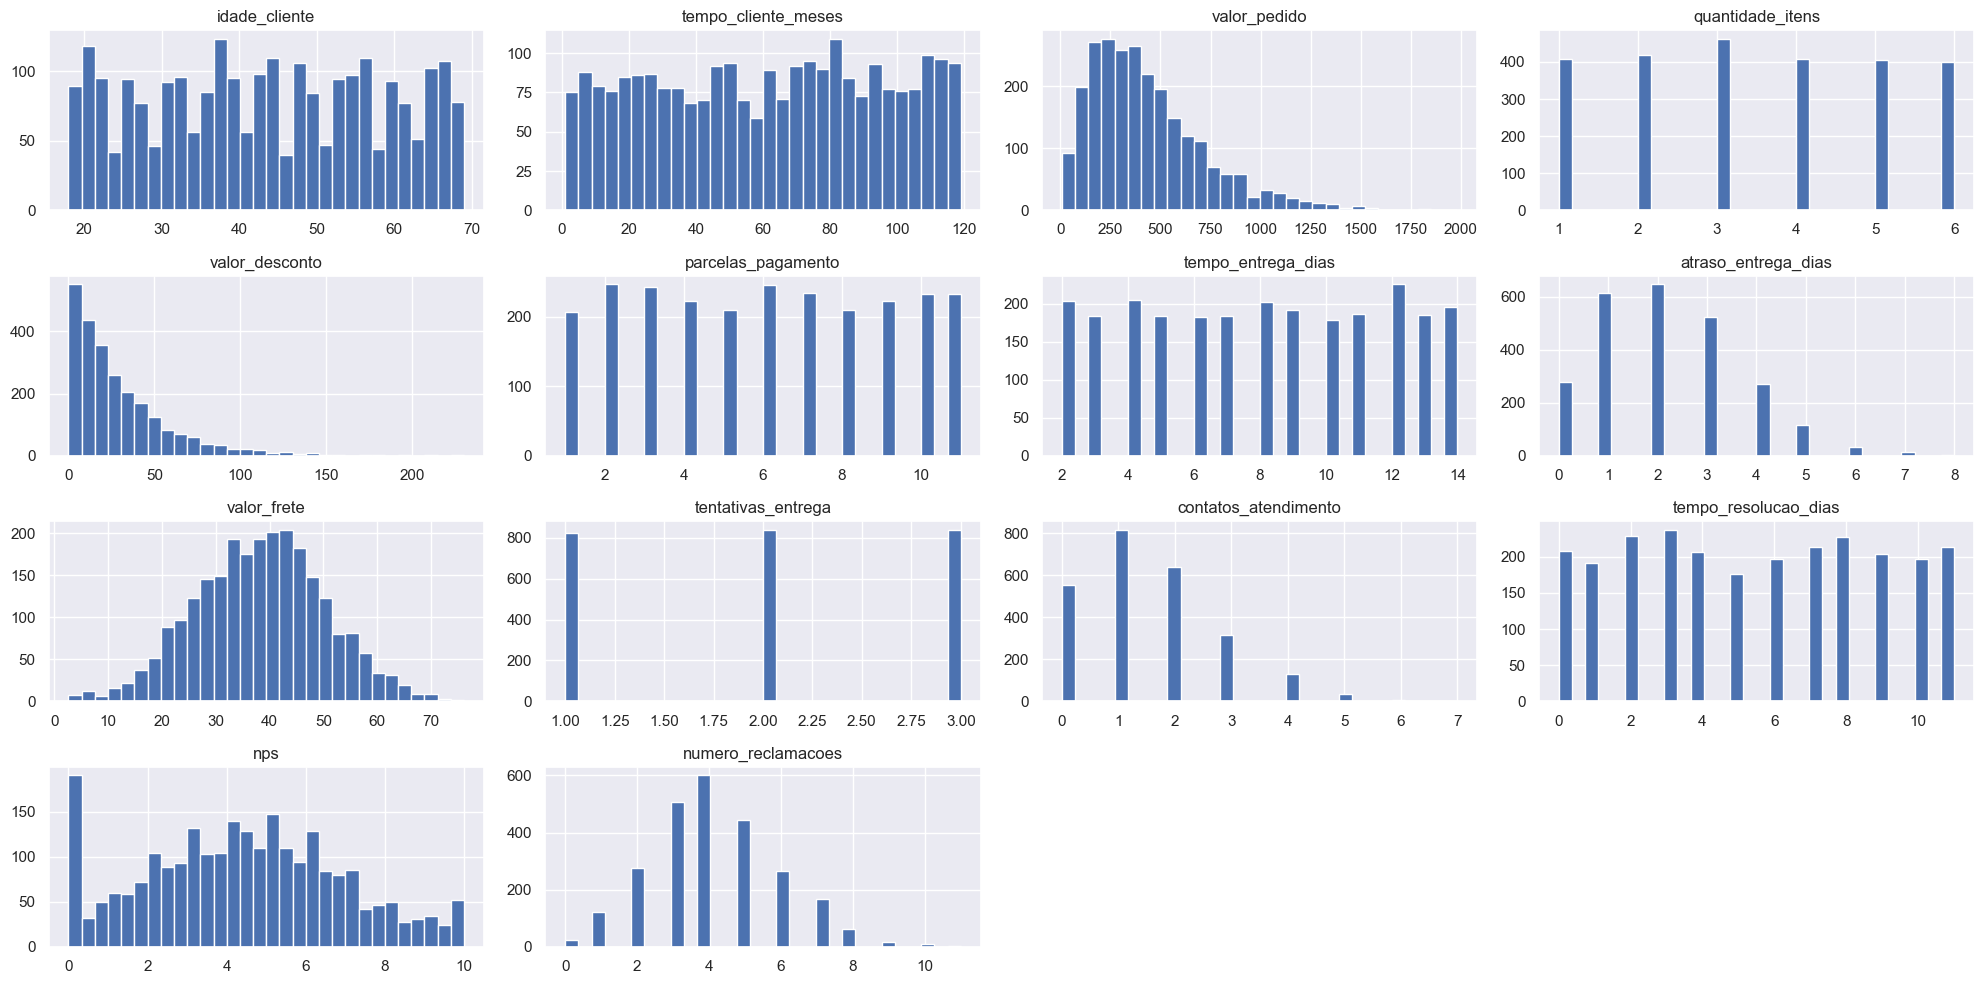

In [12]:
dados.hist(bins=30,figsize=(20,10))
plt.tight_layout()
plt.show()

#### Principais insights:

- Variáveis como **valor do pedido** e **valor de desconto** apresentam distribuição assimétrica, com concentração em valores mais baixos e poucos casos extremos  
- Variáveis operacionais, como **atraso na entrega** e **número de reclamações**, apresentam maior concentração em níveis baixos, mas com presença de casos críticos  
- Métricas de atendimento, como **contatos** e **tempo de resolução**, indicam que a maioria dos clientes tem baixa interação, com alguns casos de maior complexidade  

#### Implicações para o modelo:

As distribuições indicam a presença de assimetrias e possíveis outliers, o que reforça a importância de utilizar variáveis derivadas e modelos capazes de capturar comportamentos não lineares na experiência do cliente.

## Feature Engineering orientada aos insights da análise

Com base nos padrões identificados na análise exploratória, foram criadas variáveis derivadas com o objetivo de traduzir eventos críticos da jornada do cliente em sinais mais claros para o modelo preditivo.

A criação dessas features foi guiada principalmente pelos fatores que apresentaram maior impacto na satisfação, como atrasos na entrega, recorrência de problemas e dificuldade na resolução.

#### Principais variáveis criadas:

- **Atraso crítico (`atraso_critico`)**  
  Representa pedidos com atraso igual ou superior a 2 dias, refletindo o ponto de ruptura identificado na análise, onde a satisfação do cliente começa a cair de forma mais acentuada.

- **Problema complexo (`problema_complexo`)**  
  Combina múltiplos contatos com o atendimento e maior tempo de resolução, indicando situações em que o cliente enfrentou dificuldades na resolução de problemas ao longo da jornada.

- **Reclamação recorrente (`reclamacao_recorrente`)**  
  Identifica clientes com alto volume de reclamações, representando desgaste acumulado na experiência.


In [13]:
dados['atraso_critico'] = (dados['atraso_entrega_dias'] >= 2).astype(int)

dados['problema_complexo'] = (
    (dados['contatos_atendimento'] >= 2) &
    (dados['tempo_resolucao_dias'] >= 3)
).astype(int)

dados['reclamacao_recorrente'] = (dados['numero_reclamacoes'] >= 3).astype(int)

In [14]:
dados.head()

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,numero_reclamacoes,atraso_critico,problema_complexo,reclamacao_recorrente
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,3,1,0,1
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,3,1,0,1
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,7,0,1,1
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,4,1,0,1
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,3,0,0,1


# 4. Criação do Target e Divisão dos dados

## Criação da variável target e preparação dos dados

Para viabilizar a modelagem preditiva, foi criada uma variável target com o objetivo de identificar clientes com risco de insatisfação.

A variável foi definida da seguinte forma:
- **1 (detrator):** clientes com NPS menor ou igual a 6  
- **0 (não detrator):** clientes com NPS maior que 6  

Essa definição permite transformar o problema em uma tarefa de classificação, focada em identificar clientes com maior probabilidade de apresentar experiências negativas.


In [15]:
dados['target'] = (dados['nps'] <= 6).astype(int)

In [16]:
dados['target'].value_counts()

target
1    1851
0     649
Name: count, dtype: int64

In [17]:
dados = dados.drop('nps', axis=1)

### Divisão dos dados em treino e teste

Os dados foram separados em conjuntos de treino (80%) e teste (20%), garantindo a mesma proporção de detratores em ambos os grupos por meio da estratificação.

Essa abordagem permite avaliar o desempenho do modelo em dados não vistos, garantindo uma análise mais confiável da sua capacidade de generalização.

In [18]:
X = dados.drop('target',axis=1)
y = dados['target']

In [19]:
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, stratify=y, test_size=0.2, random_state=123)

In [20]:
colunas_entrada = x_treino.columns

In [21]:
df = x_teste.copy()

# 5.   Pré-processamento dos dados

## Pré-processamento dos dados

Para garantir a adequada utilização dos dados nos modelos de machine learning, foi aplicado um processo de pré-processamento, tratando separadamente variáveis numéricas e categóricas.

As variáveis numéricas foram padronizadas utilizando o StandardScaler, permitindo que todas fiquem na mesma escala e evitando que variáveis com maior magnitude influenciem desproporcionalmente o modelo.

Já as variáveis categóricas foram transformadas por meio de One-Hot Encoding, convertendo-as em formato numérico e possibilitando sua utilização pelos algoritmos.

Esse processo foi estruturado por meio de um pipeline, garantindo consistência no tratamento dos dados tanto no conjunto de treino quanto no de teste.

#### Insight principal:

O pré-processamento assegura que o modelo aprenda de forma mais eficiente, reduzindo vieses relacionados à escala das variáveis e permitindo a correta interpretação de informações categóricas.


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [23]:
num_pipeline = Pipeline([
    ('std_scaler', StandardScaler())
])

In [24]:
numericos = ['idade_cliente', 'tempo_cliente_meses', 'valor_pedido', 'quantidade_itens', 'valor_desconto', 'parcelas_pagamento', 'tempo_entrega_dias', 'atraso_entrega_dias',
             'valor_frete', 'tentativas_entrega', 'contatos_atendimento', 'tempo_resolucao_dias', 'numero_reclamacoes', 'atraso_critico', 'problema_complexo', 'reclamacao_recorrente']
categoricos = ['regiao_cliente']

In [25]:
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, numericos),
    ("cat", OneHotEncoder(sparse_output=False), categoricos)
])

In [26]:
x_treino_tratado = full_pipeline.fit_transform(x_treino)
x_teste_tratado = full_pipeline.transform(x_teste)

In [27]:
num_cols = list(numericos)
cat_cols = full_pipeline.named_transformers_['cat'].get_feature_names_out(categoricos)

In [28]:
X_treino = pd.DataFrame(x_treino_tratado, columns=num_cols + list(cat_cols))
X_teste = pd.DataFrame(x_teste_tratado, columns=num_cols + list(cat_cols))

In [29]:
colunas_modelo = X_treino.columns

* Resultado Pré-Processamento

In [30]:
X_treino.head()

,idade_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,...,tempo_resolucao_dias,numero_reclamacoes,atraso_critico,problema_complexo,reclamacao_recorrente,regiao_cliente_Centro-Oeste,regiao_cliente_Nordeste,regiao_cliente_Norte,regiao_cliente_Sudeste,regiao_cliente_Sul
0,-0.753729,-0.504945,-1.301223,0.910548,-0.374814,-0.627959,-0.803548,-1.517556,-0.677282,1.218805,...,0.438494,-0.087499,-1.344987,-0.715343,0.448555,0.0,0.0,1.0,0.0,0.0
1,-1.221821,-1.293601,-0.874546,-0.267773,-0.217800,1.576510,0.521128,-0.122744,-0.129364,-1.234753,...,-1.288994,0.473391,0.743502,-0.715343,0.448555,1.0,0.0,0.0,0.0,0.0
2,-0.954339,0.984740,-0.378991,-0.267773,-0.270927,-1.572731,-0.803548,0.574663,-2.282369,-1.234753,...,0.150579,1.595171,0.743502,1.397931,0.448555,0.0,0.0,0.0,1.0,0.0
3,0.249326,-0.709411,-0.655816,1.499708,-0.589016,0.631738,-1.333419,0.574663,-0.503692,-0.007974,...,0.726409,-0.648389,0.743502,-0.715343,0.448555,0.0,0.0,0.0,1.0,0.0
4,-1.489302,-1.760953,-0.512462,-1.446095,0.119916,-0.942883,-0.273678,0.574663,-0.368769,-0.007974,...,0.438494,-0.087499,0.743502,-0.715343,0.448555,0.0,0.0,0.0,1.0,0.0


# 6. Modelos de Machine Learning

Foram testados diferentes algoritmos de classificação com o objetivo de identificar clientes com risco de insatisfação.

A avaliação considerou principalmente a capacidade dos modelos de identificar corretamente os clientes detratores, métrica mais relevante para o contexto do negócio.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [32]:
# Dicionário com os principais modelos
modelos_classificacao = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),

    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),

    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced'),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "KNN Classifier": KNeighborsClassifier(n_neighbors=5),

    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),

    "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
}

In [33]:
resultados = []

for nome, modelo in modelos_classificacao.items():
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_teste, pred),
        "Precision": precision_score(y_teste, pred),
        "Recall": recall_score(y_teste, pred),
        "F1-score": f1_score(y_teste, pred)
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="F1-score", ascending=False)
resultados_df.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score
3,Gradient Boosting,0.848,0.8731,0.9297,0.9005
6,LightGBM,0.832,0.8667,0.9135,0.8895
2,Random Forest,0.826,0.8511,0.9270,0.8875
5,XGBoost,0.820,0.8684,0.8919,0.8800
4,KNN Classifier,0.810,0.8463,0.9081,0.8761
0,Logistic Regression,0.814,0.9315,0.8081,0.8654
1,Decision Tree,0.758,0.8430,0.8270,0.8349


### Comparação de desempenho

Os modelos foram comparados com base nas métricas de accuracy, precision, recall e F1-score.

#### Insight principal:

Os melhores modelos apresentaram alto recall para detratores, indicando forte capacidade de identificar clientes em risco de insatisfação, mesmo com pequenas diferenças entre eles no desempenho geral.

In [34]:
for nome in ["Gradient Boosting", "LightGBM", "Random Forest"]:
    modelo = modelos_classificacao[nome]
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)

    print(f"\n=== {nome} ===")
    print(classification_report(y_teste, pred))


=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.75      0.62      0.68       130
           1       0.87      0.93      0.90       370

    accuracy                           0.85       500
   macro avg       0.81      0.77      0.79       500
weighted avg       0.84      0.85      0.84       500


=== LightGBM ===
              precision    recall  f1-score   support

           0       0.71      0.60      0.65       130
           1       0.87      0.91      0.89       370

    accuracy                           0.83       500
   macro avg       0.79      0.76      0.77       500
weighted avg       0.83      0.83      0.83       500


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.72      0.54      0.62       130
           1       0.85      0.93      0.89       370

    accuracy                           0.83       500
   macro avg       0.79      0.73      0.75       500
weight

## Seleção dos modelos para otimização de hiperparâmetros

Com base na avaliação inicial dos modelos e na análise detalhada por meio dos classification reports, foram selecionados três algoritmos para a etapa de otimização de hiperparâmetros: Gradient Boosting, Random Forest e LightGBM.

A escolha priorizou modelos com maior capacidade de identificar corretamente os clientes detratores, métrica fundamental para o objetivo do projeto.

#### Critérios de seleção:

- Alto **recall da classe detrator**, garantindo a captura de clientes em risco  
- Bom **equilíbrio geral (F1-score)** entre precisão e recall  
- Potencial de melhoria com ajuste de hiperparâmetros  

#### Modelos selecionados:

- **Gradient Boosting:** apresentou o melhor desempenho geral, com maior F1-score e alto recall  
- **Random Forest:** modelo robusto, com desempenho consistente e alta capacidade de generalização  
- **LightGBM:** modelo eficiente, com performance competitiva e forte potencial de otimização  

#### Insight principal:

Os modelos selecionados demonstraram elevada capacidade de identificar clientes detratores, mesmo com menor desempenho na identificação de não detratores. Esse comportamento é esperado e desejável, pois o objetivo do modelo é priorizar a detecção de clientes com risco de insatisfação.

---

## Próxima etapa: otimização dos modelos

A partir dessa seleção, será realizada a otimização de hiperparâmetros com o objetivo de melhorar o desempenho dos modelos e identificar a melhor abordagem para o problema, mantendo o foco na maximização da capacidade de captura de detratores.

# 7. Tuning dos Modelos

Após a seleção dos principais modelos, foi realizada a etapa de otimização de hiperparâmetros com o objetivo de melhorar o desempenho e o equilíbrio entre as métricas.

O processo buscou ajustar os modelos para aumentar a precisão das previsões sem comprometer a capacidade de identificar clientes detratores.

In [35]:
from sklearn.model_selection import RandomizedSearchCV

# Modelos a serem utilizados
gb_model = GradientBoostingClassifier(random_state=42)

rf_model = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

lgbm_model = LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced', verbose=-1)

In [36]:
# Params Gradient Boosting
param_dist_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}
# Params Random Forest
param_dist_rf = {
    'n_estimators': [200, 300, 500],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2']
}
# Params LGBM
param_dist_lgbm = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 50],
    'max_depth': [-1, 5, 10],
    'min_child_samples': [20, 30, 50],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

### Estratégia de otimização

A otimização foi realizada utilizando busca aleatória (Randomized Search), explorando diferentes combinações de parâmetros para cada modelo.

Como critério de avaliação, foi utilizado o **F1-score**, garantindo um bom equilíbrio entre precisão e recall, com foco na identificação de clientes em risco.

In [37]:
random_gb = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist_gb,
    n_iter=20,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_lgbm = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=param_dist_lgbm,
    n_iter=20,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [38]:
random_gb.fit(X_treino, y_treino)
random_rf.fit(X_treino, y_treino)
random_lgbm.fit(X_treino, y_treino)

print("Gradient Boosting - melhores parâmetros:")
print(random_gb.best_params_)
print()

print("Random Forest - melhores parâmetros:")
print(random_rf.best_params_)
print()

print("LightGBM - melhores parâmetros:")
print(random_lgbm.best_params_)
print()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Gradient Boosting - melhores parâmetros:
{'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 4, 'learning_rate': 0.01}

Random Forest - melhores parâmetros:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15}

LightGBM - melhores parâmetros:
{'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.9}



### Resultados após otimização

Após o tuning, os modelos apresentaram melhorias no equilíbrio entre as métricas.

#### Insight principal:

O Gradient Boosting manteve o melhor desempenho geral, com alto recall e melhor F1-score, reforçando sua escolha como modelo mais aderente ao problema.

In [39]:
modelos_tunados = {
    "Gradient Boosting Tunado": random_gb.best_estimator_,
    "Random Forest Tunado": random_rf.best_estimator_,
    "LightGBM Tunado": random_lgbm.best_estimator_
}

resultados_tuning = []

for nome, modelo in modelos_tunados.items():
    pred = modelo.predict(X_teste)

    resultados_tuning.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_teste, pred),
        "Precision": precision_score(y_teste, pred, zero_division=0),
        "Recall": recall_score(y_teste, pred, zero_division=0),
        "F1-score": f1_score(y_teste, pred, zero_division=0)
    })

resultados_tuning_df = pd.DataFrame(resultados_tuning).sort_values(
    by="F1-score", ascending=False
)

resultados_tuning_df.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score
0,Gradient Boosting Tunado,0.848,0.8675,0.9378,0.9013
1,Random Forest Tunado,0.836,0.8711,0.9135,0.8918
2,LightGBM Tunado,0.826,0.8753,0.8919,0.8835


### Análise detalhada dos modelos ajustados

A análise detalhada confirmou que os modelos continuam apresentando alta capacidade de identificar detratores, com destaque para o Gradient Boosting.

#### Insight principal:

O modelo final mantém alta taxa de detecção de clientes em risco, com desempenho consistente mesmo após ajustes, reforçando sua robustez.

In [40]:
for nome in ["Gradient Boosting Tunado", "Random Forest Tunado", "LightGBM Tunado"]:
    modelo = modelos_tunados[nome]
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)

    print(f"\n=== {nome} ===")
    print(classification_report(y_teste, pred))


=== Gradient Boosting Tunado ===
              precision    recall  f1-score   support

           0       0.77      0.59      0.67       130
           1       0.87      0.94      0.90       370

    accuracy                           0.85       500
   macro avg       0.82      0.77      0.79       500
weighted avg       0.84      0.85      0.84       500


=== Random Forest Tunado ===
              precision    recall  f1-score   support

           0       0.71      0.62      0.66       130
           1       0.87      0.91      0.89       370

    accuracy                           0.84       500
   macro avg       0.79      0.76      0.78       500
weighted avg       0.83      0.84      0.83       500


=== LightGBM Tunado ===
              precision    recall  f1-score   support

           0       0.67      0.64      0.66       130
           1       0.88      0.89      0.88       370

    accuracy                           0.83       500
   macro avg       0.78      0.77      

### Matriz de confusão

A matriz de confusão evidencia o desempenho do modelo na classificação dos clientes.

O modelo apresentou alta capacidade de identificar corretamente os clientes detratores, com baixo número de falsos negativos (23 casos), indicando que poucos clientes insatisfeitos deixam de ser detectados.

Por outro lado, há um número moderado de falsos positivos, ou seja, clientes não detratores classificados como detratores.

#### Insight principal:

O modelo prioriza a identificação de clientes em risco de insatisfação, minimizando a perda de detratores, mesmo ao custo de classificar alguns clientes satisfeitos como risco. Essa abordagem é adequada ao contexto de negócio, onde o custo de não identificar um cliente insatisfeito é mais elevado.

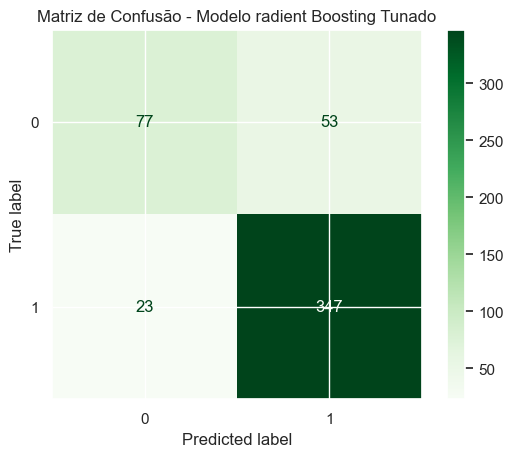

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
# Modelo final
modelo_final = random_gb.best_estimator_

# Predição
y_pred = modelo_final.predict(X_teste)

ConfusionMatrixDisplay.from_estimator(modelo_final, X_teste, y_teste, cmap='Greens')
plt.title("Matriz de Confusão - Modelo radient Boosting Tunado")
plt.show()

### Curva ROC

A curva ROC avalia a capacidade do modelo de distinguir entre clientes detratores e não detratores.

O modelo apresentou uma área sob a curva (AUC) de aproximadamente 0.89, indicando uma forte capacidade de separação entre as classes.

#### Insight principal:

O modelo demonstra boa capacidade de diferenciar clientes com maior risco de insatisfação, reforçando sua aplicabilidade como ferramenta de apoio à priorização de ações na jornada do cliente.

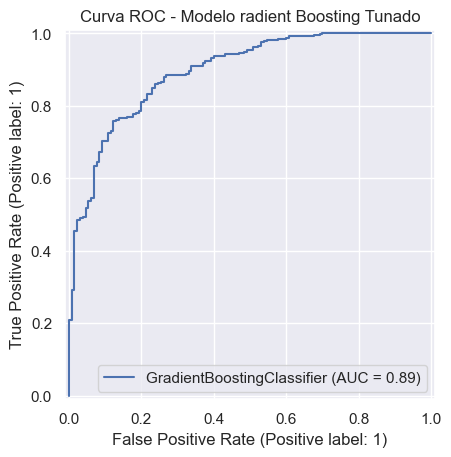

In [42]:
RocCurveDisplay.from_estimator(modelo_final, X_teste, y_teste)
plt.title("Curva ROC - Modelo radient Boosting Tunado")
plt.show()

# 8. Cross Validate Modelo Gradient Boosting

In [43]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# Modelo final
modelo_final = random_gb.best_estimator_

# Estratégia de validação cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Métricas avaliadas
metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Cross-validation
cv_resultados = cross_validate(estimator=modelo_final, X=X_treino, y=y_treino, cv=cv, scoring=metricas, n_jobs=-1)

In [44]:
# Organizando resultados
cv_df = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Média': [
        cv_resultados['test_accuracy'].mean(),
        cv_resultados['test_precision'].mean(),
        cv_resultados['test_recall'].mean(),
        cv_resultados['test_f1'].mean(),
        cv_resultados['test_roc_auc'].mean()
    ],
    'Desvio padrão': [
        cv_resultados['test_accuracy'].std(),
        cv_resultados['test_precision'].std(),
        cv_resultados['test_recall'].std(),
        cv_resultados['test_f1'].std(),
        cv_resultados['test_roc_auc'].std()
    ]
})

cv_df.round(4)

,Métrica,Média,Desvio padrão
0,Accuracy,0.8360,0.0085
1,Precision,0.8522,0.0060
2,Recall,0.9419,0.0134
3,F1-score,0.8948,0.0058
4,ROC-AUC,0.8716,0.0163


## Validação cruzada do modelo final

Para avaliar a robustez do modelo, foi realizada validação cruzada utilizando estratégia estratificada, garantindo a preservação da proporção entre detratores e não detratores em cada divisão.

#### Resultados médios:

- **Accuracy:** 0.836  
- **Precision:** 0.852  
- **Recall:** 0.942  
- **F1-score:** 0.895  
- **ROC-AUC:** 0.872  

#### Estabilidade do modelo:

As métricas apresentaram baixo desvio padrão entre os folds, indicando que o desempenho do modelo se mantém consistente em diferentes subconjuntos da base.

#### Insight principal:

O modelo demonstrou alta capacidade de identificar clientes detratores de forma consistente, mantendo desempenho estável mesmo em diferentes divisões dos dados. Isso reforça sua confiabilidade e aplicabilidade em cenários reais.

# 9. Geração de Valor para o E-commerce

## Geração de valor para o negócio

A partir do modelo treinado, foi possível estimar a probabilidade de cada cliente se tornar um detrator.

Essa probabilidade foi utilizada para transformar a previsão do modelo em uma métrica prática de risco, permitindo direcionar ações de forma mais estratégica.

In [45]:
df['prob_detrator'] = modelo_final.predict_proba(X_teste)[:,1]

### Construção da métrica de risco

A probabilidade de ser detrator foi utilizada como base para segmentar os clientes em diferentes níveis de risco:

- **Seguro:** baixo risco de insatisfação  
- **Neutro:** risco moderado  
- **Atenção:** risco elevado  
- **Crítico:** alto risco de se tornar detrator  

Essa segmentação permite identificar rapidamente quais clientes precisam de atenção prioritária.

In [46]:
df['Segmentacao_Cliente'] = pd.cut(
    df['prob_detrator'],
    bins=[-1, 0.3, 0.6, 0.8, 1],
    labels=['Seguro', 'Neutro', 'Atenção', 'Crítico']
)

### Priorização de clientes

Para direcionar melhor os esforços da empresa, foi criada uma métrica de prioridade financeira, combinando:

- Risco de insatisfação  
- Valor do pedido  

Essa métrica permite identificar clientes que, além de estarem em risco, possuem maior impacto financeiro para o negócio.

In [47]:
df['Prioridade_Financeira'] = df['prob_detrator'] * df['valor_pedido']

### Definição de ações

Com base na segmentação de risco, foram definidas ações para cada grupo de clientes:

- Clientes **Críticos:** ações mais agressivas (ex: descontos maiores)  
- Clientes **Atenção:** ações intermediárias  
- Clientes **Neutros:** ações leves  
- Clientes **Seguros:** sem necessidade de ação  

Essa abordagem permite atuar de forma proporcional ao risco.

In [48]:
def definir_desconto(segmento):
    if segmento == 'Crítico':
        return 40
    elif segmento == 'Atenção':
        return 20
    elif segmento == 'Neutro':
        return 10
    else:
        return 0

df['Desconto'] = df['Segmentacao_Cliente'].apply(definir_desconto)

### Insight principal

O modelo permite não apenas prever quais clientes estão em risco, mas também priorizar ações com base no impacto financeiro.

Isso possibilita uma atuação mais eficiente, direcionando esforços para os clientes que realmente importam, reduzindo perdas e melhorando a experiência do cliente.

In [49]:
df[['prob_detrator', 'Segmentacao_Cliente', 'Prioridade_Financeira', 'Desconto']].head()

,prob_detrator,Segmentacao_Cliente,Prioridade_Financeira,Desconto
462,0.154913,Seguro,43.008511,0
474,0.963460,Crítico,252.754028,40
255,0.948827,Crítico,799.054456,40
274,0.968566,Crítico,307.142037,40
582,0.683240,Atenção,103.715806,20


# 10. Salvando o Modelo e Pipeline

In [ ]:
import joblib

# Salvando o modelo predititvo
joblib.dump(modelo_final, 'modelo_gradiente_boosting.pkl')

# Salvando o pipeline de pré-processamento
joblib.dump(full_pipeline, 'pre_processamento.pkl')

# Salvando nome colunas de entrada
joblib.dump(colunas_entrada, 'colunas_entrada.pkl')

# Salvando nome colunas do modelo
joblib.dump(colunas_modelo, 'colunas_modelo.pkl')

['colunas_modelo.pkl']

# Aplicação da solução na prática

A solução desenvolvida utiliza o modelo de **Gradient Boosting** para identificar, de forma antecipada, clientes com maior risco de insatisfação, a partir de dados operacionais da jornada.

Em vez de aguardar o fim da experiência para medir o NPS, o modelo permite estimar a **probabilidade de um cliente se tornar detrator**, viabilizando uma atuação mais **proativa e orientada por dados**.

Essa probabilidade é transformada em uma métrica de risco, utilizada para segmentar os clientes em níveis de prioridade:

- Seguro  
- Neutro  
- Atenção  
- Crítico  

Essa segmentação permite identificar rapidamente quais clientes demandam ação imediata.

Além disso, foi criada uma métrica de **prioridade financeira**, que combina o risco de insatisfação com o valor do pedido. Com isso, a empresa consegue direcionar esforços não apenas para clientes em risco, mas principalmente para aqueles com **maior impacto potencial na receita**.

A partir dessa priorização, é possível estruturar ações práticas, como:

- oferta de incentivos para clientes críticos  
- priorização de atendimentos mais sensíveis  
- intervenções direcionadas em pontos críticos da jornada (ex: atrasos, reclamações)

O modelo também permite entender quais fatores mais influenciam a insatisfação, apoiando decisões estratégicas em áreas como logística e atendimento.

#### Resultado prático

A solução transforma a previsão em uma ferramenta de decisão, permitindo:

- antecipar clientes em risco  
- priorizar ações com maior impacto financeiro  
- otimizar a alocação de recursos  
- reduzir perdas de receita  
- melhorar a experiência do cliente  

Consolidando uma abordagem orientada por dados, com foco em **prevenção de problemas e geração de valor para o negócio**.